In [1]:
import nest
import os
import network
import addons
import helpers
import matplotlib.pyplot as plt
import numpy as np
from network_params import net_dict
import network_params
from sim_params import sim_dict
from stimulus_params import stim_dict


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Sep 26 2025 04:43:14

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



/home/hyc_1/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning:Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.


In [2]:
#name_of_data = "data_background_rate_fig_1_lesion"
name_of_data =  "data_background_rate_fig_1"

In [3]:
dirs = os.listdir(name_of_data)
dirs = sorted(dirs)
#rates = np.linspace(5,20,len(dirs))
rates = np.zeros(len(dirs))

labels_rate = ["6 spikes/s", "9 spikes/s", "12 spikes/s", "18 spikes/s"]
neurons = {}
times = {}

for i in range(len(dirs)):
    name = name_of_data + "/" + dirs[i] + "/trial_0/"
    neurons[i] = []
    times[i] = []
    sd_names, node_ids, data = helpers.__load_spike_times(name,"spike_recorder",addons.analysis_dict["analysis_start"], addons.analysis_dict["analysis_end"])
    last_node_id = node_ids[-1, -1]
    mod_node_ids = np.abs(node_ids - last_node_id) + 1
    for j, n in enumerate(sd_names):
        times[i].append(data[j]["time_ms"])
        neurons[i].append(np.abs(data[j]["sender"] - last_node_id) + 1)

In [4]:
dirs = os.listdir(name_of_data)
dirs = sorted(dirs)
#rates = np.linspace(5,20,len(dirs))
rates = np.zeros(len(dirs))

labels_rate = ["6 spikes/s", "9 spikes/s", "12 spikes/s", "18 spikes/s"]
names = [6,9,12,18]
pop_activity = np.zeros((len(dirs),3,25000))

freq_sample = 0.0002

for i in range(len(dirs)):
    name = name_of_data + "/" + dirs[i] + "/trial_0/"
    for j in range(3):
        name_2 = name + "measurements/pop_activities2/pop_activity_" + str(j*2) + ".dat"
        pop_activity[i][j] = np.loadtxt(name_2)

Drive 6 spikes/s   → χ = [0.00935086 0.02117087 0.05036916 0.0246705 ]
Drive 9 spikes/s   → χ = [0.06387902 0.06552013 0.09430466 0.02267243]
Drive 12 spikes/s  → χ = [0.09857055 0.08976136 0.13769406 0.02095875]
Drive 18 spikes/s  → χ = [0.17084346 0.15368621 0.26306845 0.0161725 ]


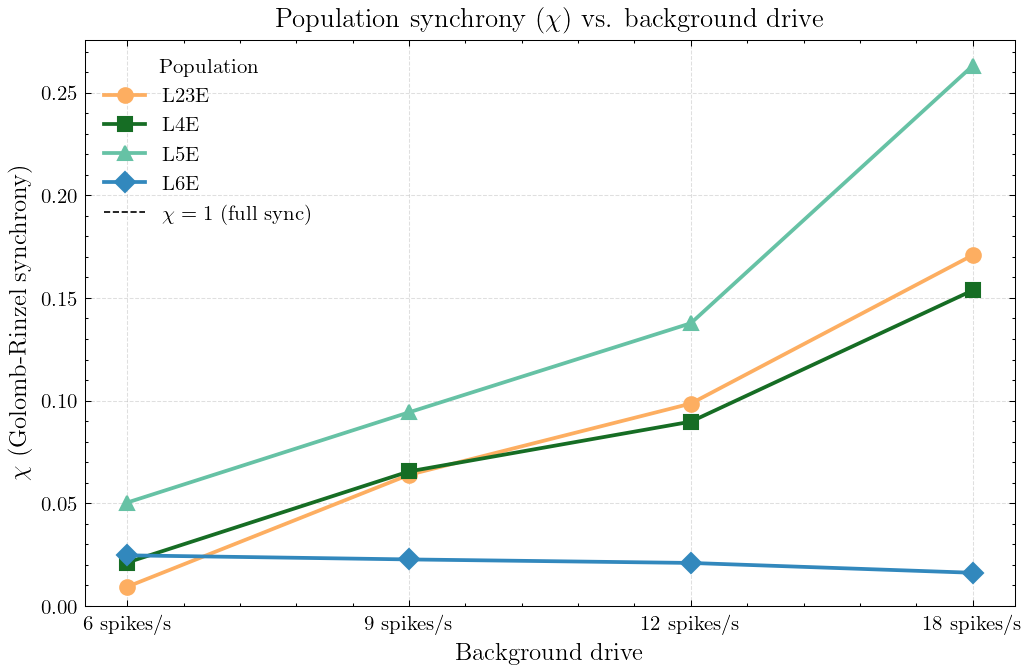

In [16]:
from scipy.signal import hilbert, find_peaks
import numpy as np
import matplotlib.pyplot as plt

# ── Chi (χ) synchrony measure — Golomb & Rinzel ───────────────────────────────
# χ² = Var(V_mean) / mean(Var(V_i))
# Here we use spike trains binned into a continuous signal as proxy for V_i

def compute_chi(times_i, neurons_i, n_neurons, bin_width=1.0,
                t_start=None, t_end=None):
    """
    Golomb-Rinzel χ synchrony measure from spike train data.

    Parameters
    ----------
    times_i   : list of arrays, times_i[pop] → spike times for that population
    neurons_i : list of arrays, neurons_i[pop] → neuron IDs for that population
    n_neurons : list of ints, number of neurons per population
    bin_width : float, bin width in ms for converting spikes → rate signal
    t_start   : float, start of analysis window (ms); inferred if None
    t_end     : float, end of analysis window (ms); inferred if None

    Returns
    -------
    chi : ndarray, shape (n_pops,)  — χ value per population
    """
    n_pops = len(times_i)
    chi    = np.full(n_pops, np.nan)

    for pop in range(n_pops):
        spike_times = np.array(times_i[pop])
        spike_ids   = np.array(neurons_i[pop])

        if len(spike_times) == 0:
            continue

        t0 = t_start if t_start is not None else spike_times.min()
        t1 = t_end   if t_end   is not None else spike_times.max()

        bins    = np.arange(t0, t1 + bin_width, bin_width)
        n_bins  = len(bins) - 1
        N       = n_neurons[pop]

        if n_bins < 2 or N < 2:
            continue

        # ── population mean signal: binned spike count across all neurons ─────
        pop_mean, _ = np.histogram(spike_times, bins=bins)
        pop_mean    = pop_mean.astype(float) / N          # mean firing per bin

        var_pop_mean = np.var(pop_mean, ddof=1)           # Var( <V>(t) )

        # ── per-neuron variance: bin each neuron's spike train ────────────────
        unique_ids   = np.unique(spike_ids)
        var_per_cell = np.zeros(len(unique_ids))

        for k, nid in enumerate(unique_ids):
            mask              = spike_ids == nid
            cell_train, _     = np.histogram(spike_times[mask], bins=bins)
            var_per_cell[k]   = np.var(cell_train.astype(float), ddof=1)

        mean_var_cells = np.mean(var_per_cell)            # <Var(V_i)>

        if mean_var_cells > 0:
            chi[pop] = np.sqrt(var_pop_mean / mean_var_cells)   # χ
        else:
            chi[pop] = np.nan

    return chi


# ── Load neuron counts from net_dict (adjust keys to match your network) ──────
# These should be the excitatory population sizes you are recording from
# e.g. L23E, L4E, L5E, L6E → populations 0,2,4,6 in your spike recorders
n_neurons_per_pop = [
    net_dict['full_num_neurons'][0],   # L23E
    net_dict['full_num_neurons'][2],   # L4E
    net_dict['full_num_neurons'][4],   # L5E
    net_dict['full_num_neurons'][6],   # L6E
]

layers      = ["L23E", "L4E", "L5E", "L6E"]
colors_pops = ['#fdae61', '#166d24', '#66c2a5', '#3288bd']
#layers      = ["L23E", "L4E", "L6E"]
#colors_pops = ['#fdae61', '#166d24', '#3288bd']
n_pops      = len(layers)
n_drives    = len(dirs)

# ── Compute χ for every drive ─────────────────────────────────────────────────
# chi_matrix shape: (n_pops, n_drives)
chi_matrix = np.full((n_pops, n_drives), np.nan)

for i in range(n_drives):
    # neurons[i] and times[i] are lists indexed by spike recorder (all pops)
    # keep only the 4 excitatory populations (indices 0,2,4,6 → every other)
    times_exc   = [times[i][p]   for p in range(0, 2 * n_pops, 2)]
    neurons_exc = [neurons[i][p] for p in range(0, 2 * n_pops, 2)]

    chi_i = compute_chi(
        times_exc, neurons_exc,
        n_neurons = n_neurons_per_pop,
        bin_width = 1.0,             # 1 ms bins — adjust if needed
        t_start   = t_start,
        t_end     = t_end
    )
    chi_matrix[:, i] = chi_i
    print(f"Drive {labels_rate[i]:12s} → χ = {chi_i}")


# ── Plot χ vs drive ───────────────────────────────────────────────────────────
x       = np.arange(n_drives)
markers = ['o', 's', '^', 'D']

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

for pop_idx in range(n_pops):
    ax.plot(
        x, chi_matrix[pop_idx],
        marker    = markers[pop_idx],
        color     = colors_pops[pop_idx],
        linewidth = 1.8,
        markersize= 7,
        label     = layers[pop_idx]
    )
ax.set_xlabel("Background drive", fontsize=12)
ax.set_ylabel(r"$\chi$ (Golomb-Rinzel synchrony)", fontsize=12)
ax.set_title(r"Population synchrony ($\chi$) vs. background drive", fontsize=13)

ax.set_ylim(bottom=0)
ax.axhline(1, color='k', linestyle='--', linewidth=0.8, label=r'$\chi=1$ (full sync)')
ax.legend(title="Population", framealpha=0.8)   
ax.grid(True, linestyle='--', alpha=0.4)

ax.set_xticks(x)
ax.set_xticklabels(labels_rate)
#plt.savefig("chi_synchrony_vs_drive.svg", bbox_inches='tight', dpi=300)
plt.show()

Drive 6 spikes/s   → F_true = [0.99721059 0.95949983 0.8393285  0.95848256]
Drive 9 spikes/s   → F_true = [0.97698015 0.88202778 0.83177384 0.98004486]
Drive 12 spikes/s  → F_true = [0.98615374 0.86105898 0.84213373 0.9866472 ]
Drive 18 spikes/s  → F_true = [1.01444684 0.90781103 1.04171816 1.03941327]


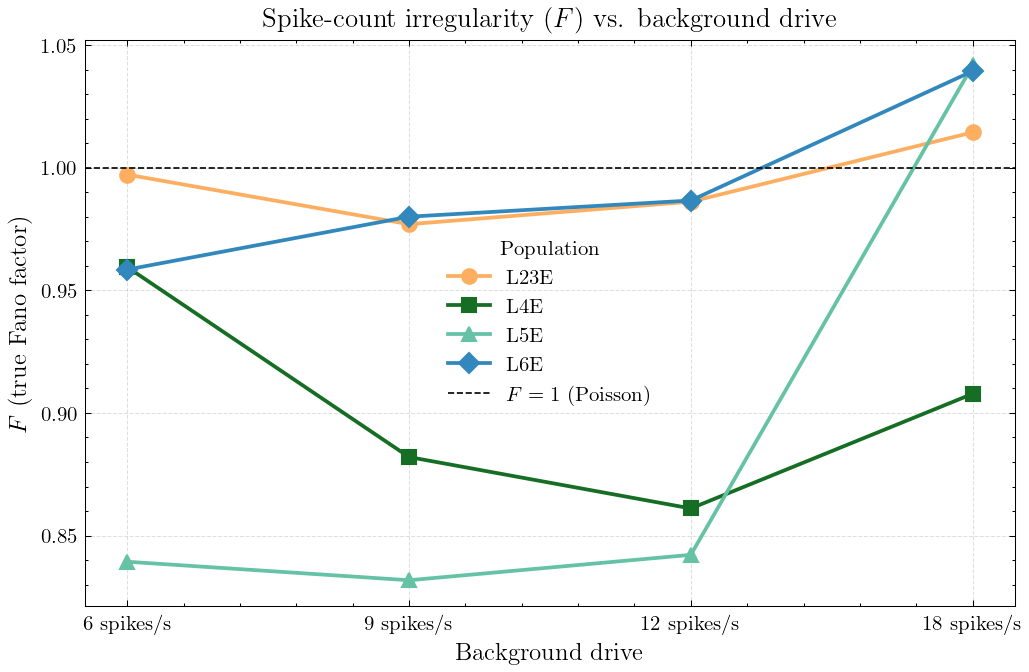

In [ ]:
# ── True Fano factor: F = Var(spike_count) / Mean(spike_count) ────────────
# Computed per neuron across time bins, then averaged over the population.

def compute_true_fano(times_i, neurons_i, n_neurons, bin_width=50.0,
                       t_start=None, t_end=None, min_mean_count=1e-9):
    """
    True Fano factor per population: Var(count)/Mean(count), computed
    per neuron over repeated time bins, then averaged across neurons.

    Parameters
    ----------
    times_i        : list of arrays, times_i[pop] → spike times for that population
    neurons_i      : list of arrays, neurons_i[pop] → neuron IDs for that population
    n_neurons      : list of ints, number of neurons per population
    bin_width      : float, window size in ms for counting spikes (larger than
                     for the χ² measure — Fano factor needs enough spikes/bin
                     to be meaningful, e.g. 50-100 ms rather than 1 ms)
    t_start        : float, start of analysis window (ms); inferred if None
    t_end          : float, end of analysis window (ms); inferred if None
    min_mean_count : float, skip neurons with mean count below this (avoid /0)

    Returns
    -------
    F        : ndarray, shape (n_pops,) — population-averaged Fano factor
    F_per_neuron : list of ndarrays — per-neuron Fano factors (for distributions)
    """
    n_pops = len(times_i)
    F = np.full(n_pops, np.nan)
    F_per_neuron = [np.array([]) for _ in range(n_pops)]

    for pop in range(n_pops):
        spike_times = np.array(times_i[pop])
        spike_ids   = np.array(neurons_i[pop])
        N = n_neurons[pop]

        if len(spike_times) == 0 or N < 2:
            continue

        t0 = t_start if t_start is not None else spike_times.min()
        t1 = t_end   if t_end   is not None else spike_times.max()
        bins = np.arange(t0, t1 + bin_width, bin_width)
        n_bins = len(bins) - 1

        if n_bins < 2:
            continue

        # use the IDs actually present, not an assumed 1..N range
        unique_ids = np.unique(spike_ids)
        fano_vals = []
        for nid in unique_ids:
            mask = spike_ids == nid
            counts, _ = np.histogram(spike_times[mask], bins=bins)
            counts = counts.astype(float)
            mean_count = counts.mean()
            if mean_count < min_mean_count:
                continue
            var_count = counts.var(ddof=1)
            fano_vals.append(var_count / mean_count)

        fano_vals = np.array(fano_vals)
        F_per_neuron[pop] = fano_vals
        F[pop] = fano_vals.mean() if len(fano_vals) > 0 else np.nan

    return F, F_per_neuron


# ── Compute true Fano factor for every drive ───────────────────────────────
FanoTrue_matrix = np.full((n_pops, n_drives), np.nan)
FanoTrue_per_neuron = {}  # FanoTrue_per_neuron[i] = list of arrays per pop


for i in range(n_drives):
    times_exc   = [times[i][p]   for p in range(0, 2 * n_pops, 2)]
    neurons_exc = [neurons[i][p] for p in range(0, 2 * n_pops, 2)]

    F_i, F_pn_i = compute_true_fano(
        times_exc, neurons_exc,
        n_neurons  = n_neurons_per_pop,
        bin_width  = 10.0,     # ms — tune based on firing rates; needs enough
                                # spikes/bin for count variance to be meaningful
        t_start    = t_start,
        t_end      = t_end
    )
    FanoTrue_matrix[:, i] = F_i
    FanoTrue_per_neuron[i] = F_pn_i
    print(f"Drive {labels_rate[i]:12s} → F_true = {F_i}")


# ── Plot true Fano factor vs drive ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

for pop_idx in range(n_pops):
    ax.plot(
        x, FanoTrue_matrix[pop_idx],
        marker     = markers[pop_idx],
        color      = colors_pops[pop_idx],
        linewidth  = 1.8,
        markersize = 7,
        label      = layers[pop_idx]
    )
ax.set_xlabel("Background drive", fontsize=12)
ax.set_ylabel(r"$F$ (true Fano factor)", fontsize=12)
ax.set_title(r"Spike-count irregularity ($F$) vs. background drive", fontsize=13)

ax.axhline(1, color='k', linestyle='--', linewidth=0.8, label=r'$F=1$ (Poisson)')
ax.legend(title="Population", framealpha=0.8)
ax.grid(True, linestyle='--', alpha=0.4)

ax.set_xticks(x)
ax.set_xticklabels(labels_rate)
plt.show()

Drive 6 spikes/s   → F_single_bin = [1.42268377 3.88548333 6.97574001 5.82459981]
Drive 9 spikes/s   → F_single_bin = [ 8.55487827 14.9078763  20.35108314  9.63756345]
Drive 12 spikes/s  → F_single_bin = [14.64240912 22.11620049 29.84772829 11.03812057]
Drive 18 spikes/s  → F_single_bin = [33.47827538 45.96678145 64.64962571 18.43547386]


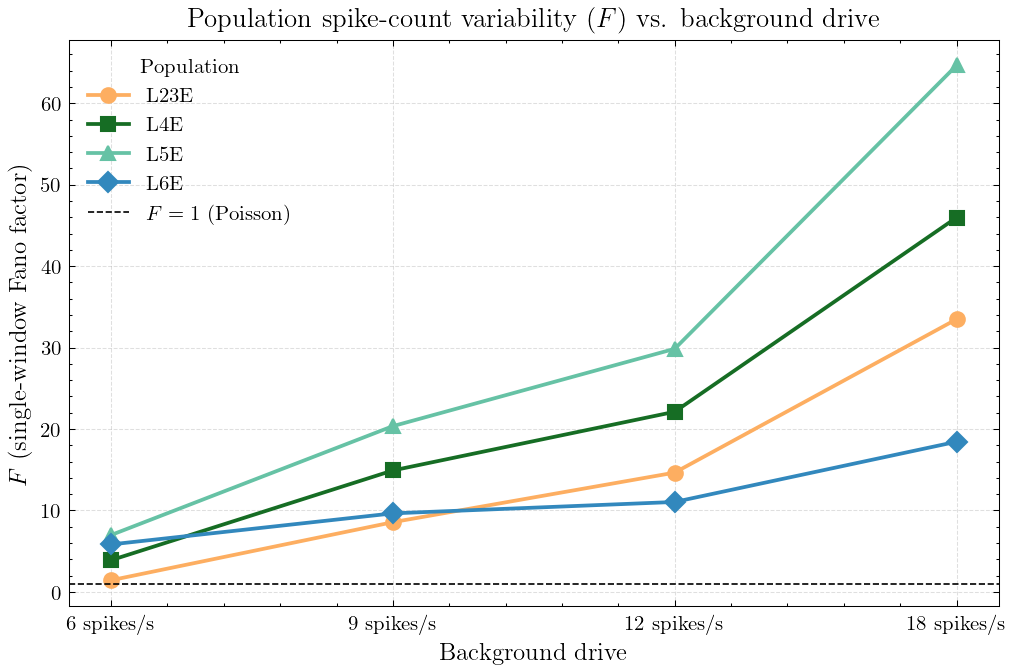

In [18]:
# ── Single-window Fano factor: F = Var(counts across neurons) / Mean(counts across neurons) ──
# One spike count per neuron over the entire analysis window (single bin),
# then Fano factor is computed across the population rather than across time.

def compute_fano_single_bin(times_i, neurons_i, n_neurons,
                             t_start=None, t_end=None, min_mean_count=1e-9):
    """
    Fano factor per population using a single time bin covering the whole
    analysis window: F = Var(spike counts across neurons) / Mean(spike counts
    across neurons). Silent neurons are included (count=0), since they are
    part of the population variance.

    Parameters
    ----------
    times_i        : list of arrays, times_i[pop] → spike times for that population
    neurons_i      : list of arrays, neurons_i[pop] → neuron IDs for that population
    n_neurons      : list of ints, number of neurons per population
    t_start        : float, start of analysis window (ms); inferred if None
    t_end          : float, end of analysis window (ms); inferred if None
    min_mean_count : float, skip population if mean count is ~0 (avoid /0)

    Returns
    -------
    F         : ndarray, shape (n_pops,) — Fano factor per population
    counts_out: list of ndarrays, shape (N,) — per-neuron spike counts (for inspection)
    """
    n_pops = len(times_i)
    F = np.full(n_pops, np.nan)
    counts_out = [np.array([]) for _ in range(n_pops)]

    for pop in range(n_pops):
        spike_times = np.array(times_i[pop])
        spike_ids   = np.array(neurons_i[pop])
        N = n_neurons[pop]

        if N < 2:
            continue

        t0 = t_start if t_start is not None else (spike_times.min() if len(spike_times) else 0)
        t1 = t_end   if t_end   is not None else (spike_times.max() if len(spike_times) else 0)

        # one count per neuron ID actually present; silent neurons get 0
        unique_ids, raw_counts = np.unique(spike_ids, return_counts=True)
        counts = np.zeros(N)

        # only keep spikes inside [t0, t1] — np.unique above counted ALL
        # spikes regardless of window, so recompute counts restricted to window
        in_window = (spike_times >= t0) & (spike_times <= t1)
        ids_in_window = spike_ids[in_window]
        unique_ids, raw_counts = np.unique(ids_in_window, return_counts=True)

        # map counts into a length-N array; unmatched IDs beyond N are ignored
        # (shouldn't happen if IDs are consistent with n_neurons, but guards
        # against silently underestimating N if ID mapping is off — see the
        # id-range diagnostic from before if this looks wrong)
        counts[:len(unique_ids)] = 0  # placeholder, real assignment below
        count_map = dict(zip(unique_ids, raw_counts))
        counts = np.array([count_map.get(nid, 0) for nid in range(int(unique_ids.min()) if len(unique_ids) else 1,
                                                                     (int(unique_ids.min()) if len(unique_ids) else 1) + N)]) \
                 if len(unique_ids) > 0 else np.zeros(N)

        counts_out[pop] = counts

        mean_count = counts.mean()
        if mean_count < min_mean_count:
            F[pop] = np.nan
            continue

        var_count = counts.var(ddof=1)
        F[pop] = var_count / mean_count

    return F, counts_out


# ── Compute single-bin Fano factor for every drive ──────────────────────────
FanoSingleBin_matrix = np.full((n_pops, n_drives), np.nan)
FanoSingleBin_counts = {}

for i in range(n_drives):
    times_exc   = [times[i][p]   for p in range(0, 2 * n_pops, 2)]
    neurons_exc = [neurons[i][p] for p in range(0, 2 * n_pops, 2)]

    F_i, counts_i = compute_fano_single_bin(
        times_exc, neurons_exc,
        n_neurons = n_neurons_per_pop,
        t_start   = t_start,
        t_end     = t_end
    )
    FanoSingleBin_matrix[:, i] = F_i
    FanoSingleBin_counts[i] = counts_i
    print(f"Drive {labels_rate[i]:12s} → F_single_bin = {F_i}")


# ── Plot single-bin Fano factor vs drive ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

for pop_idx in range(n_pops):
    ax.plot(
        x, FanoSingleBin_matrix[pop_idx],
        marker     = markers[pop_idx],
        color      = colors_pops[pop_idx],
        linewidth  = 1.8,
        markersize = 7,
        label      = layers[pop_idx]
    )
ax.set_xlabel("Background drive", fontsize=12)
ax.set_ylabel(r"$F$ (single-window Fano factor)", fontsize=12)
ax.set_title(r"Population spike-count variability ($F$) vs. background drive", fontsize=13)

ax.axhline(1, color='k', linestyle='--', linewidth=0.8, label=r'$F=1$ (Poisson)')
ax.legend(title="Population", framealpha=0.8)
ax.grid(True, linestyle='--', alpha=0.4)

ax.set_xticks(x)
ax.set_xticklabels(labels_rate)
plt.show()

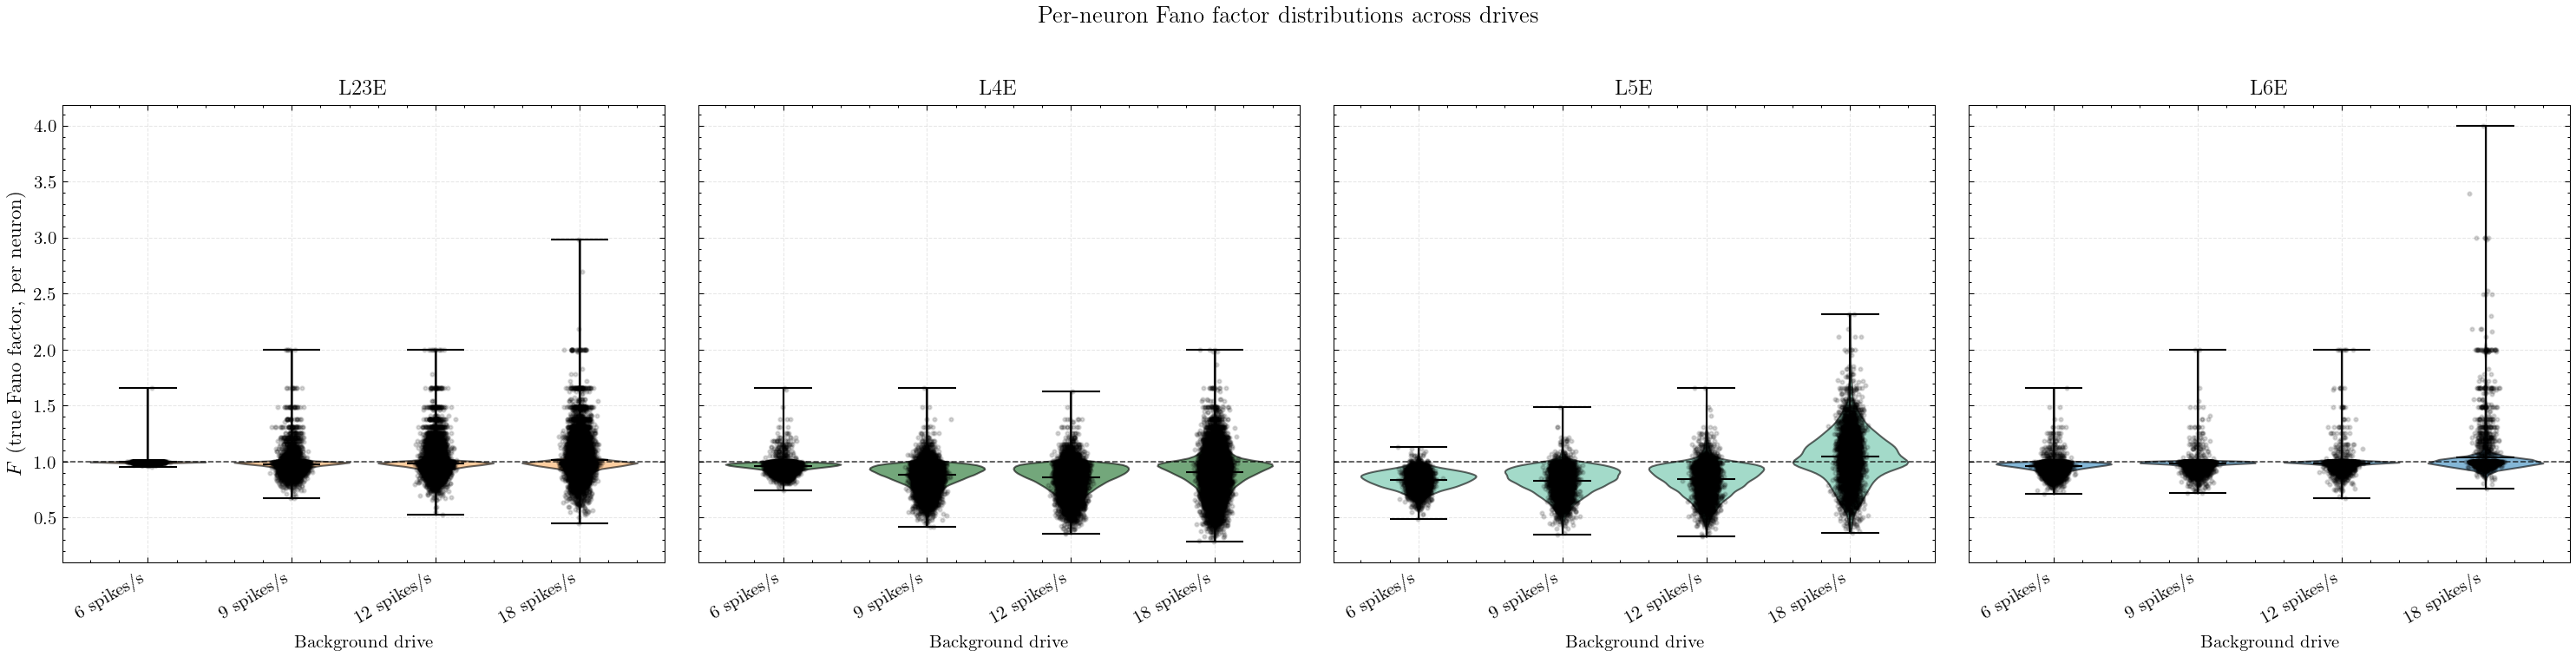

In [15]:
# ── Per-neuron Fano factor distributions (violin plots) ────────────────────
# Shows the full distribution across neurons for each population/drive combo,
# since the population mean alone can hide skew or bimodality.

fig, axes = plt.subplots(1, n_pops, figsize=(5 * n_pops, 5), dpi=150, sharey=True)

if n_pops == 1:
    axes = [axes]

for pop_idx in range(n_pops):
    ax = axes[pop_idx]

    # gather per-neuron Fano values for this population, across all drives
    data_per_drive = []
    labels_present = []
    for i in range(n_drives):
        vals = FanoTrue_per_neuron[i][pop_idx]
        if len(vals) > 0:
            data_per_drive.append(vals)
            labels_present.append(labels_rate[i])

    if len(data_per_drive) == 0:
        ax.set_title(f"{layers[pop_idx]} (no data)")
        continue

    parts = ax.violinplot(
        data_per_drive,
        showmeans=True,
        showextrema=True,
        widths=0.8
    )

    # color violins to match the population's color from the line plots
    for pc in parts['bodies']:
        pc.set_facecolor(colors_pops[pop_idx])
        pc.set_edgecolor('black')
        pc.set_alpha(0.6)
    for key in ('cbars', 'cmins', 'cmaxes', 'cmeans'):
        if key in parts:
            parts[key].set_color('black')
            parts[key].set_linewidth(1.0)

    # overlay individual points with jitter for a sense of sample size / spread
    for j, vals in enumerate(data_per_drive):
        jitter = np.random.normal(0, 0.04, size=len(vals))
        ax.scatter(np.full(len(vals), j + 1) + jitter, vals,
                   s=4, color='black', alpha=0.15, zorder=2)

    ax.axhline(1, color='k', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.set_xticks(np.arange(1, len(labels_present) + 1))
    ax.set_xticklabels(labels_present, rotation=30, ha='right')
    ax.set_title(layers[pop_idx], fontsize=12)
    ax.set_xlabel("Background drive", fontsize=10)
    if pop_idx == 0:
        ax.set_ylabel(r"$F$ (true Fano factor, per neuron)", fontsize=11)
    ax.grid(True, linestyle='--', alpha=0.3)

fig.suptitle("Per-neuron Fano factor distributions across drives", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

Drive 6 spikes/s    L23E  → <CV_ISI> = 0.715  (n=1195 cells)
Drive 6 spikes/s    L4E   → <CV_ISI> = 0.832  (n=20074 cells)
Drive 6 spikes/s    L5E   → <CV_ISI> = 0.796  (n=4850 cells)
Drive 6 spikes/s    L6E   → <CV_ISI> = 0.832  (n=12465 cells)
Drive 9 spikes/s    L23E  → <CV_ISI> = 0.837  (n=13978 cells)
Drive 9 spikes/s    L4E   → <CV_ISI> = 0.831  (n=21354 cells)
Drive 9 spikes/s    L5E   → <CV_ISI> = 0.809  (n=4784 cells)
Drive 9 spikes/s    L6E   → <CV_ISI> = 0.816  (n=6115 cells)
Drive 12 spikes/s   L23E  → <CV_ISI> = 0.881  (n=15294 cells)
Drive 12 spikes/s   L4E   → <CV_ISI> = 0.829  (n=21339 cells)
Drive 12 spikes/s   L5E   → <CV_ISI> = 0.836  (n=4725 cells)
Drive 12 spikes/s   L6E   → <CV_ISI> = 0.814  (n=3805 cells)
Drive 18 spikes/s   L23E  → <CV_ISI> = 0.990  (n=15639 cells)
Drive 18 spikes/s   L4E   → <CV_ISI> = 0.926  (n=21195 cells)
Drive 18 spikes/s   L5E   → <CV_ISI> = 1.059  (n=4672 cells)
Drive 18 spikes/s   L6E   → <CV_ISI> = 0.902  (n=1531 cells)


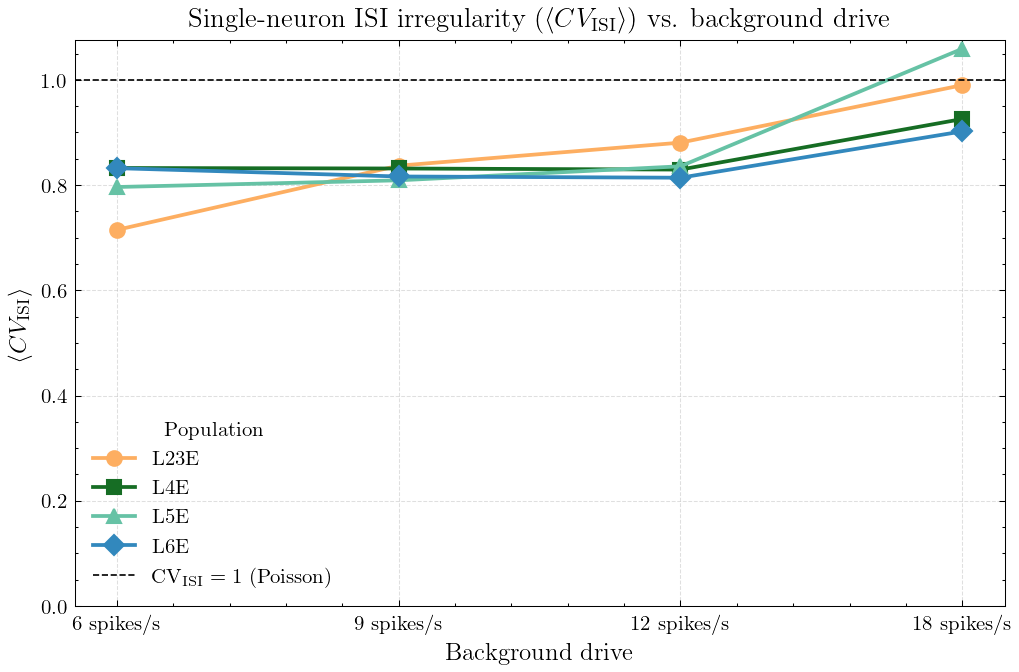

In [8]:
# ── CV of ISI: single-neuron irregularity averaged across cells ───────────────
# CV_ISI = std(ISI) / mean(ISI) per cell, then averaged across cells per pop

def compute_cv_isi(times_i, neurons_i, min_spikes=3):
    """
    Mean CV of ISI across neurons for a single population.

    Parameters
    ----------
    times_i   : array of spike times (ms) for the population
    neurons_i : array of neuron IDs corresponding to each spike
    min_spikes: int, minimum spikes a neuron must have to be included

    Returns
    -------
    mean_cv  : float, mean CV_ISI across qualifying neurons
    n_cells  : int, number of neurons that contributed
    """
    spike_times = np.array(times_i)
    spike_ids   = np.array(neurons_i)

    if len(spike_times) == 0:
        return np.nan, 0

    unique_ids = np.unique(spike_ids)
    cvs = []

    for nid in unique_ids:
        mask  = spike_ids == nid
        times = np.sort(spike_times[mask])

        if len(times) < min_spikes:
            continue

        isis = np.diff(times)          # inter-spike intervals
        mean_isi = np.mean(isis)

        if mean_isi > 0:
            cvs.append(np.std(isis, ddof=1) / mean_isi)

    if len(cvs) == 0:
        return np.nan, 0

    return np.mean(cvs), len(cvs)


# ── Compute CV_ISI for every population × drive ───────────────────────────────
# cv_matrix shape: (n_pops, n_drives)
layers    = ["L23E", "L4E", "L5E", "L6E"]
#layers    = ["L23E", "L4E", "L6E"]
n_pops    = len(layers)
n_drives  = len(dirs)

cv_matrix      = np.full((n_pops, n_drives), np.nan)
cv_ncells      = np.zeros((n_pops, n_drives), dtype=int)

for i in range(n_drives):
    # excitatory populations are at even indices (0, 2, 4, 6)
    for pop_idx in range(n_pops):
        rec_idx = pop_idx * 2
        mean_cv, n_cells = compute_cv_isi(
            times[i][rec_idx],
            neurons[i][rec_idx],
            min_spikes=3
        )
        cv_matrix[pop_idx, i]  = mean_cv
        cv_ncells[pop_idx, i]  = n_cells
        print(f"Drive {labels_rate[i]:12s}  {layers[pop_idx]:5s} → "
              f"<CV_ISI> = {mean_cv:.3f}  (n={n_cells} cells)")


# ── Plot CV_ISI vs drive ──────────────────────────────────────────────────────
colors_pops = ['#fdae61', '#166d24', '#66c2a5', '#3288bd']
#colors_pops = ['#fdae61', '#166d24', '#3288bd']
markers     = ['o', 's', '^', 'D']
x           = np.arange(n_drives)

fig, ax = plt.subplots(figsize=(8, 5), dpi=150)

for pop_idx in range(n_pops):
    ax.plot(
        x, cv_matrix[pop_idx],
        marker     = markers[pop_idx],
        color      = colors_pops[pop_idx],
        linewidth  = 1.8,
        markersize = 7,
        label      = layers[pop_idx]
    )

ax.axhline(1.0, color='k', linestyle='--', linewidth=0.8,
           label=r'CV$_\mathrm{ISI}=1$ (Poisson)')
ax.set_xlabel("Background drive", fontsize=12)
ax.set_ylabel(r"$\langle CV_\mathrm{ISI} \rangle$", fontsize=12)
ax.set_title(r"Single-neuron ISI irregularity ($\langle CV_\mathrm{ISI} \rangle$) vs. background drive",
             fontsize=13)
ax.set_ylim(bottom=0)
ax.set_xticks(x)
ax.set_xticklabels(labels_rate)
ax.legend(title="Population", framealpha=0.8)
ax.grid(True, linestyle='--', alpha=0.4)

# plt.savefig("cv_isi_vs_drive.svg", bbox_inches='tight', dpi=300)
plt.show()